# Step 2 — Bigger Models, Default Prompt

Etap 2: modele 24B–32B, prompt `default_pl/new_graph`, 3 artykuły, porównanie z Claude Opus 4.6 jako referencją.

In [1]:
import pandas as pd

df = pd.read_csv("step_2_bigger_models_default.csv")
df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]

def short_label(m):
    if m.startswith("local:"):
        m = m[len("local:"):]
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ")

NUMERIC = ["precision", "recall", "t_precision", "t_recall", "connectivity"]

print(f"{len(df)} rows | {df['model'].nunique()} models | {df['title'].nunique()} articles")
df.dtypes

18 rows | 6 models | 3 articles


position          int64
id                int64
title               str
model               str
prompt              str
precision       float64
recall          float64
hall                str
miss                str
t_precision     float64
t_recall        float64
t_hall              str
t_miss              str
connectivity    float64
model_short         str
title_short         str
dtype: object

## Pełna tabela wyników (per artykuł, posortowana po Precision)

In [2]:
from IPython.display import display, HTML

display_cols = ["model_short", "title_short", "precision", "recall", "hall", "miss",
                "t_precision", "t_recall", "t_hall", "t_miss", "connectivity"]

rename_map = {
    "model_short": "Model", "title_short": "Artykuł",
    "precision": "Prec.", "recall": "Recall",
    "hall": "Hall.", "miss": "Miss.",
    "t_precision": "T-Prec.", "t_recall": "T-Recall",
    "t_hall": "T-Hall.", "t_miss": "T-Miss.",
    "connectivity": "Connect.",
}

for article, group in df.groupby("title_short"):
    display(HTML(f"<h3>{article}</h3>"))
    styled = (
        group[display_cols]
        .sort_values("precision", ascending=False)
        .rename(columns=rename_map)
        .style
        .background_gradient(subset=["Prec.", "Recall", "T-Prec.", "T-Recall"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Connect."], cmap="Blues", vmin=0, vmax=1)
        .format({
            "Prec.": "{:.1%}",
            "Recall": "{:.1%}",
            "T-Prec.": "{:.1%}",
            "T-Recall": "{:.1%}",
            "Connect.": "{:.3f}",
        })
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )
    display(styled)

Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
nemotron-3-nano-30b-a3b,Langer serial SkyShowtime,100.0%,53.6%,0 | 15,13 | 28,100.0%,22.7%,0 | 15,51 | 66,0.348
mistral-small-3.2-24b-instruct,Langer serial SkyShowtime,97.9%,64.8%,1 | 47,25 | 71,93.6%,66.7%,3 | 47,22 | 66,1.000
gemma-4-26b-a4b-it,Langer serial SkyShowtime,95.8%,56.1%,1 | 24,18 | 41,95.8%,34.8%,1 | 24,43 | 66,1.000
gemma-4-31b-it,Langer serial SkyShowtime,90.9%,62.5%,2 | 22,12 | 32,100.0%,33.3%,0 | 22,44 | 66,1.000
qwen3-30b-a3b-instruct-2507,Langer serial SkyShowtime,80.0%,48.8%,5 | 25,21 | 41,96.0%,36.4%,1 | 25,42 | 66,0.786
qwen3-32b,Langer serial SkyShowtime,75.0%,63.8%,10 | 40,17 | 47,90.0%,54.5%,4 | 40,30 | 66,1.000


Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
gemma-4-31b-it,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,71.0%,0 | 22,9 | 31,90.9%,55.6%,2 | 22,16 | 36,1.000
nemotron-3-nano-30b-a3b,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,38.9%,0 | 7,11 | 18,71.4%,13.9%,2 | 7,31 | 36,0.500
qwen3-30b-a3b-instruct-2507,The Last of Us odcinek 5 tworcy o szokujacych scenach,92.1%,79.5%,3 | 38,9 | 44,55.3%,58.3%,17 | 38,15 | 36,0.872
gemma-4-26b-a4b-it,The Last of Us odcinek 5 tworcy o szokujacych scenach,86.4%,63.3%,3 | 22,11 | 30,86.4%,52.8%,3 | 22,17 | 36,0.905
mistral-small-3.2-24b-instruct,The Last of Us odcinek 5 tworcy o szokujacych scenach,77.8%,63.6%,6 | 27,12 | 33,77.8%,58.3%,6 | 27,15 | 36,0.429
qwen3-32b,The Last of Us odcinek 5 tworcy o szokujacych scenach,70.8%,51.5%,7 | 24,16 | 33,66.7%,44.4%,8 | 24,20 | 36,0.818


Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
gemma-4-31b-it,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,76.7%,0 | 46,14 | 60,91.3%,60.0%,4 | 46,28 | 70,1.000
mistral-small-3.2-24b-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,78.8%,0 | 52,14 | 66,86.5%,64.3%,7 | 52,25 | 70,0.849
nemotron-3-nano-30b-a3b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,22.7%,0 | 5,17 | 22,100.0%,7.1%,0 | 5,65 | 70,0.714
qwen3-30b-a3b-instruct-2507,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,93.9%,53.4%,2 | 33,27 | 58,84.8%,40.0%,5 | 33,42 | 70,0.882
qwen3-32b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,92.5%,60.7%,3 | 40,24 | 61,80.0%,45.7%,8 | 40,38 | 70,1.000
gemma-4-26b-a4b-it,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,90.7%,79.0%,5 | 54,13 | 62,87.0%,67.1%,7 | 54,23 | 70,0.855


## Średnie per model — ranking wg Precision i T-Precision

In [3]:
for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>"))
    summary = (
        df.groupby("model_short")[NUMERIC]
        .mean()
        .sort_values(sort_col, ascending=False)
        .round(3)
    )
    display(
        summary.style
        .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
    )

summary = (
    df.groupby("model_short")[NUMERIC]
    .mean()
    .sort_values("t_precision", ascending=False)
    .round(3)
)

,precision,recall,t_precision,t_recall,connectivity
model_short,,,,,
nemotron-3-nano-30b-a3b,100.0%,38.4%,90.5%,14.6%,52.1%
gemma-4-31b-it,97.0%,70.1%,94.1%,49.6%,100.0%
mistral-small-3.2-24b-instruct,91.9%,69.1%,86.0%,63.1%,75.9%
gemma-4-26b-a4b-it,91.0%,66.1%,89.7%,51.6%,92.0%
qwen3-30b-a3b-instruct-2507,88.7%,60.6%,78.7%,44.9%,84.7%
qwen3-32b,79.4%,58.7%,78.9%,48.2%,93.9%


,precision,recall,t_precision,t_recall,connectivity
model_short,,,,,
gemma-4-31b-it,97.0%,70.1%,94.1%,49.6%,100.0%
nemotron-3-nano-30b-a3b,100.0%,38.4%,90.5%,14.6%,52.1%
gemma-4-26b-a4b-it,91.0%,66.1%,89.7%,51.6%,92.0%
mistral-small-3.2-24b-instruct,91.9%,69.1%,86.0%,63.1%,75.9%
qwen3-32b,79.4%,58.7%,78.9%,48.2%,93.9%
qwen3-30b-a3b-instruct-2507,88.7%,60.6%,78.7%,44.9%,84.7%


## Pivot: metryki per model × artykuł

In [4]:
for metric in ["precision", "recall", "t_precision", "t_recall"]:
    pivot = df.pivot_table(index="model_short", columns="title_short", values=metric)
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
        .set_caption(metric.replace("_", "-").upper())
    )

title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
gemma-4-26b-a4b-it,95.8%,86.4%,90.7%
gemma-4-31b-it,90.9%,100.0%,100.0%
mistral-small-3.2-24b-instruct,97.9%,77.8%,100.0%
nemotron-3-nano-30b-a3b,100.0%,100.0%,100.0%
qwen3-30b-a3b-instruct-2507,80.0%,92.1%,93.9%
qwen3-32b,75.0%,70.8%,92.5%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
gemma-4-26b-a4b-it,56.1%,63.3%,79.0%
gemma-4-31b-it,62.5%,71.0%,76.7%
mistral-small-3.2-24b-instruct,64.8%,63.6%,78.8%
nemotron-3-nano-30b-a3b,53.6%,38.9%,22.7%
qwen3-30b-a3b-instruct-2507,48.8%,79.5%,53.4%
qwen3-32b,63.8%,51.5%,60.7%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
gemma-4-26b-a4b-it,95.8%,86.4%,87.0%
gemma-4-31b-it,100.0%,90.9%,91.3%
mistral-small-3.2-24b-instruct,93.6%,77.8%,86.5%
nemotron-3-nano-30b-a3b,100.0%,71.4%,100.0%
qwen3-30b-a3b-instruct-2507,96.0%,55.3%,84.8%
qwen3-32b,90.0%,66.7%,80.0%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
gemma-4-26b-a4b-it,34.8%,52.8%,67.1%
gemma-4-31b-it,33.3%,55.6%,60.0%
mistral-small-3.2-24b-instruct,66.7%,58.3%,64.3%
nemotron-3-nano-30b-a3b,22.7%,13.9%,7.1%
qwen3-30b-a3b-instruct-2507,36.4%,58.3%,40.0%
qwen3-32b,54.5%,44.4%,45.7%


## Wykresy słupkowe

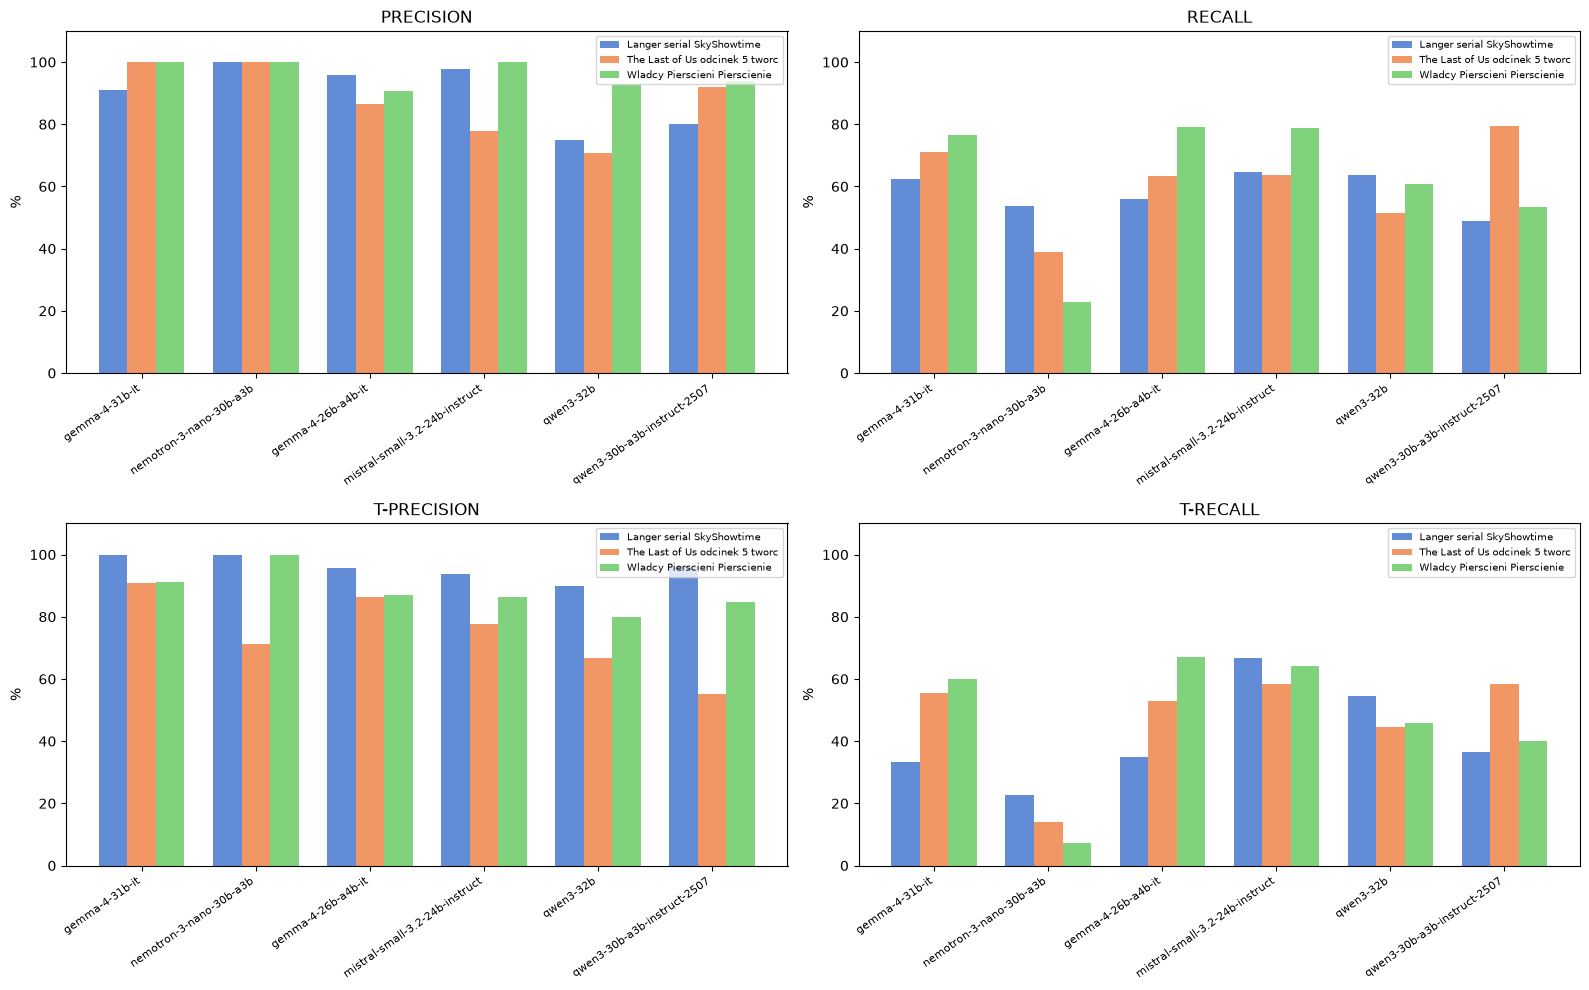

In [5]:
import matplotlib.pyplot as plt
import numpy as np

model_order = summary.index.tolist()
articles = df["title_short"].unique()
colors = ["#4878d0", "#ee854a", "#6acc65"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, ["precision", "recall", "t_precision", "t_recall"]):
    pivot = df.pivot_table(index="model_short", columns="title_short", values=metric).reindex(model_order) * 100
    x = np.arange(len(model_order))
    w = 0.25
    for i, (art, color) in enumerate(zip(pivot.columns, colors)):
        ax.bar(x + (i - 1) * w, pivot[art], w, label=art[:30], color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(metric.replace("_", "-").upper())
    ax.legend(fontsize=7)

# fig.suptitle("Etap 2 — Bigger Models, Default Prompt", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

Wnioski:

 1. gemma-4-31b — najwyższa Precision (0.970) i T-Precision (0.941) w całej grupie. Na artykule Last of Us i Władcy Pierścieni osiąga pełne 1.0 Precision bez żadnych halucynacji.
  T-Recall (0.496) jest jednak umiarkowany — model ekstraktoruje trafnie, ale nie wyciąga wszystkich relacji.

  2. mistral-small-24b — najlepszy model jeśli patrzeć na T-F1 (0.728). Wyróżnia się zdecydowanie najwyższym T-Recall (0.631) przy jednoczesnej dobrej T-Precision (0.860). Oznacza
  to że semantycznie trafia w relacje referencyjne i nie pomija ich zbyt dużo. Jedyna słabość to artykuł Last of Us gdzie Precision spada do 0.778.

  3. gemma-4-26b — bardzo zbliżony do gemma-4-31b, nieznacznie niższa T-Precision (0.897) ale nieco lepszy T-Recall (0.516). Solidny i konsekwentny we wszystkich 3 artykułach, brak
  wyraźnych słabości.

  4. qwen3-32b — wyniki poniżej oczekiwań jak na 32B model. Precision tylko 0.794, T-Precision 0.789. Szczególnie słabo na Last of Us (Precision 0.708). Może mieć problemy z
  halucynacjami — na Langer 10 z 40 relacji niepopartych.

  5. qwen3-30b — niejednorodny. Na Last of Us bardzo dobry Recall (0.795) ale jednocześnie niska T-Precision (0.553) — co sugeruje że ekstraktoruje dużo relacji, ale semantycznie
  nie pokrywają się z referencją. Na Langer odwrotnie — T-Precision 0.960 ale Recall tylko 0.488.

  6. nemotron-30b — paradoks: perfekcyjna Precision (1.000 na wszystkich 3 artykułach) ale katastrofalny T-Recall (0.146). Ekstraktoruje bardzo mało relacji (5–15 zamiast 66–70 w
  referencji) — wszystkie trafne, ale pomija ~85% grafu. Praktycznie bezużyteczny jako ekstraktor grafów wiedzy.